In [1]:
# Packages
from pyspark.sql import SparkSession
import pandas as pd
import openpyxl

In [2]:
# Create a SparkSession
spark = SparkSession.builder \
    .appName("BDA Exam") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark

26/04/19 08:11:25 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 192.168.100.197 instead (on interface en0)
26/04/19 08:11:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/19 08:11:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Read Excel with pandas
pdf = pd.read_excel("data/raw/online_retail_II.xlsx", engine="openpyxl")

# Convert to PySpark DataFrame
df = spark.createDataFrame(pdf)
df.show()

26/04/19 08:12:51 WARN TaskSetManager: Stage 0 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|RECORD FRAME 7" S...|      48|2009-12-01 07:45:00|  2.1|    13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00| 1.25|    13085.0|United Kingdom|
| 489434|    22064|PINK DOUGHNUT TRI...|      24|2009-12-01 07:45:00| 1.65|    13085.0|United Kingdom|
| 489434|    21871| SAVE THE PLANET MUG|      24|2009-12-01 07:45:00| 1.2

In [4]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)



In [5]:
row_count = df.count()
print(f"Total rows: {row_count}")

26/04/19 08:12:53 WARN TaskSetManager: Stage 1 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Total rows: 525461


In [6]:
from pyspark.sql.functions import desc
df.groupBy("Country").count().orderBy("count", ascending=False).show()

26/04/19 08:12:55 WARN TaskSetManager: Stage 4 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+------+
|             Country| count|
+--------------------+------+
|      United Kingdom|485852|
|                EIRE|  9670|
|             Germany|  8129|
|              France|  5772|
|         Netherlands|  2769|
|               Spain|  1278|
|         Switzerland|  1187|
|            Portugal|  1101|
|             Belgium|  1054|
|     Channel Islands|   906|
|              Sweden|   902|
|               Italy|   731|
|           Australia|   654|
|              Cyprus|   554|
|             Austria|   537|
|              Greece|   517|
|United Arab Emirates|   432|
|             Denmark|   428|
|              Norway|   369|
|             Finland|   354|
+--------------------+------+
only showing top 20 rows



## Missing Data

In [7]:
from pyspark.sql import functions as F

# Create a list of 'count' expressions for each column
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) 
    for c in df.columns
])

# Show the results
null_counts.show()

26/04/19 08:12:57 WARN TaskSetManager: Stage 7 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|Customer ID|Country|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|      0|        0|          0|       0|          0|    0|          0|      0|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+



26/04/19 08:12:58 WARN TaskSetManager: Stage 10 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


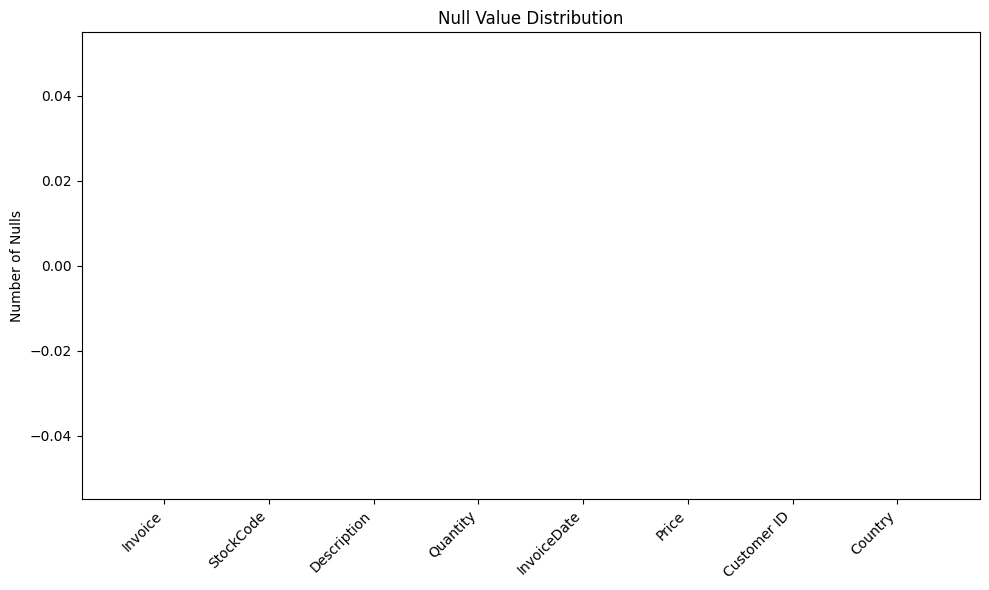

In [8]:
import matplotlib.pyplot as plt

# 1. Convert the tiny summary to a Pandas DataFrame
pd_nulls = null_counts.toPandas().transpose()
pd_nulls.columns = ['null_count']
pd_nulls.index.name = 'column_name'
pd_nulls.reset_index(inplace=True)

# 2. Plot
plt.figure(figsize=(10, 6))
plt.bar(pd_nulls['column_name'], pd_nulls['null_count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Nulls')
plt.title('Null Value Distribution')
plt.tight_layout()
plt.show()

In [9]:
# Check for duplicates
total_count = df.count()
distinct_count = df.distinct().count()

if total_count > distinct_count:
    print(f"Duplicates found! There are {total_count - distinct_count} duplicate rows.")
else:
    print("No exact duplicate rows found in the data, nothing to worry about there!")

26/04/19 08:12:59 WARN TaskSetManager: Stage 13 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 08:12:59 WARN TaskSetManager: Stage 16 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Duplicates found! There are 6865 duplicate rows.


In [10]:
duplicate_rows = df.groupBy(df.columns) \
                   .count() \
                   .filter(F.col("count") > 1) \
                   .orderBy(F.desc("count"))

duplicate_rows.show()

26/04/19 08:13:01 WARN TaskSetManager: Stage 22 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+-----+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|count|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+-----+
| 496431|    84826|ASSTD DESIGN 3D P...|       1|2010-02-01 12:30:00| 0.85|    16415.0|United Kingdom|    6|
| 525065|    20894|HANGING BAUBLE T-...|       1|2010-10-03 14:28:00| 2.95|    16799.0|United Kingdom|    6|
| 502660|    17021|NAMASTE SWAGAT IN...|       6|2010-03-25 17:18:00|  0.3|    13187.0|United Kingdom|    6|
| 534219|    35953|FOLKART STAR CHRI...|       1|2010-11-21 16:13:00| 1.25|    13230.0|United Kingdom|    6|
| 520570|    21754|HOME BUILDING BLO...|       1|2010-08-26 20:07:00| 5.95|    16549.0|United Kingdom|    5|
| 492784|    22114|HOT WATER BOTTLE ...|       1|2009-12-18 17:24:00| 3.95|    17841.0|United Kingdom|    5|
| 520570|    21755|

In [11]:
duplicate_rows = df.groupBy(["Invoice"]) \
                   .count() \
                   .filter(F.col("count") > 1) \
                   .orderBy(F.desc("count"))

duplicate_rows.show()

26/04/19 08:13:03 WARN TaskSetManager: Stage 25 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+-----+
|Invoice|count|
+-------+-----+
| 537434|  675|
| 538071|  652|
| 537638|  601|
| 537237|  597|
| 536876|  593|
| 536592|  592|
| 537823|  591|
| 536031|  582|
| 490074|  580|
| 491966|  579|
| 537240|  568|
| 490149|  559|
| 491969|  548|
| 490741|  546|
| 537666|  536|
| 536544|  527|
| 489857|  516|
| 513574|  515|
| 490745|  507|
| 489597|  502|
+-------+-----+
only showing top 20 rows



In [12]:
# Visualize duplication hotspots
# See which countries have the most duplicate invoice IDs
df.groupBy("Country", "Invoice") \
  .count() \
  .filter("count > 1") \
  .groupBy("Country") \
  .sum("count") \
  .show()

26/04/19 08:13:04 WARN TaskSetManager: Stage 28 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+----------+
|             Country|sum(count)|
+--------------------+----------+
|                EIRE|      9544|
|United Arab Emirates|       424|
|           Australia|       641|
|             Austria|       530|
|              Norway|       363|
|              Israel|        74|
|             Iceland|        71|
|         Netherlands|      2739|
|     Channel Islands|       890|
|              Cyprus|       553|
|             Belgium|      1036|
|             Finland|       349|
|               Spain|      1256|
|               Italy|       720|
|               Japan|       211|
|              Sweden|       883|
|                 RSA|       109|
|             Bermuda|        34|
|           Hong Kong|        72|
|            Thailand|        76|
+--------------------+----------+
only showing top 20 rows



In [13]:
# High level comparison of duplicates
from pyspark.sql import functions as F

stats = df.select(
    F.count("*").alias("total_rows"),
    F.countDistinct("Invoice").alias("unique_invoices"),
    F.countDistinct(*df.columns).alias("unique_entire_rows")
)

stats.show()

26/04/19 08:13:06 WARN TaskSetManager: Stage 34 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+----------+---------------+------------------+
|total_rows|unique_invoices|unique_entire_rows|
+----------+---------------+------------------+
|    525461|          28816|            518596|
+----------+---------------+------------------+



Having `unique_entire_rows > unique_invoices` is a "Data Variance" scenario. It means we have the same `Invoice` appearing multiple times, but the data in the other columns is different (e.g., different items, different timestamps, or different prices). To identify the "Data Variance" Rows, and see the specific `Invoice` that have conflicting or multiple entries with different data, we group by the `Invoice` and count the distinct versions of the row.

In [14]:
# Find Invoice IDs that have more than one version of "the rest of the data"
variance_df = df.groupBy("Invoice") \
    .agg(F.countDistinct(*[c for c in df.columns if c != "Invoice"]).alias("versions")) \
    .filter("versions > 1") \
    .orderBy(F.desc("versions"))

variance_df.show()

26/04/19 08:13:08 WARN TaskSetManager: Stage 40 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+--------+
|Invoice|versions|
+-------+--------+
| 537434|     675|
| 538071|     652|
| 537638|     601|
| 537237|     597|
| 536876|     593|
| 536592|     592|
| 537823|     591|
| 536031|     582|
| 490074|     580|
| 491966|     579|
| 537240|     568|
| 490149|     559|
| 491969|     548|
| 490741|     546|
| 537666|     536|
| 536544|     527|
| 489857|     516|
| 513574|     515|
| 490745|     507|
| 489597|     502|
+-------+--------+
only showing top 20 rows



In [15]:
# Get a list of IDs with multiple data versions
problem_ids = [row.Invoice for row in variance_df.limit(5).collect()]

# Display the actual data for those IDs
df.filter(F.col("Invoice").isin(problem_ids)).orderBy("Invoice").show()

26/04/19 08:13:10 WARN TaskSetManager: Stage 46 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 08:13:12 WARN TaskSetManager: Stage 52 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 536876|    21993|FLORAL FOLK STATI...|       3|2010-12-03 11:36:00| 2.51|        NaN|United Kingdom|
| 536876|    22028|PENNY FARTHING BI...|       1|2010-12-03 11:36:00| 0.85|        NaN|United Kingdom|
| 536876|    22041|RECORD FRAME 7" S...|       1|2010-12-03 11:36:00| 5.06|        NaN|United Kingdom|
| 536876|    22042|CHRISTMAS CARD SI...|       1|2010-12-03 11:36:00| 0.43|        NaN|United Kingdom|
| 536876|    22059|CERAMIC STRAWBERR...|       1|2010-12-03 11:36:00| 3.36|        NaN|United Kingdom|
| 536876|    22067|CHOC TRUFFLE GOLD...|       1|2010-12-03 11:36:00| 3.36|        NaN|United Kingdom|
| 536876|    22069|BROWN  PIRATE TRE...|       2|2010-12-03 11:36:00| 3.3

In [16]:
## Sales Time Series

from pyspark.sql import functions as F

# 1. Prepare the date column
df_orders = df.withColumn("Date", F.to_date("InvoiceDate"))

# 2. Get the Top 5 countries by order volume to keep the chart clean
top_countries = df_orders.groupBy("Country") \
                         .agg(F.countDistinct("Invoice").alias("TotalOrders")) \
                         .orderBy(F.desc("TotalOrders")) \
                         .limit(5) \
                         .select("Country") \
                         .rdd.flatMap(lambda x: x).collect()

# 3. Filter and aggregate by Date and Country
daily_order_counts = df_orders.filter(F.col("Country").isin(top_countries)) \
                              .groupBy("Date", "Country") \
                              .agg(F.countDistinct("Invoice").alias("OrderCount")) \
                              .orderBy("Date")

# 4. Convert the summary to Pandas
pd_orders = daily_order_counts.toPandas()

26/04/19 08:13:13 WARN TaskSetManager: Stage 53 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/19 08:13:14 WARN TaskSetManager: Stage 59 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


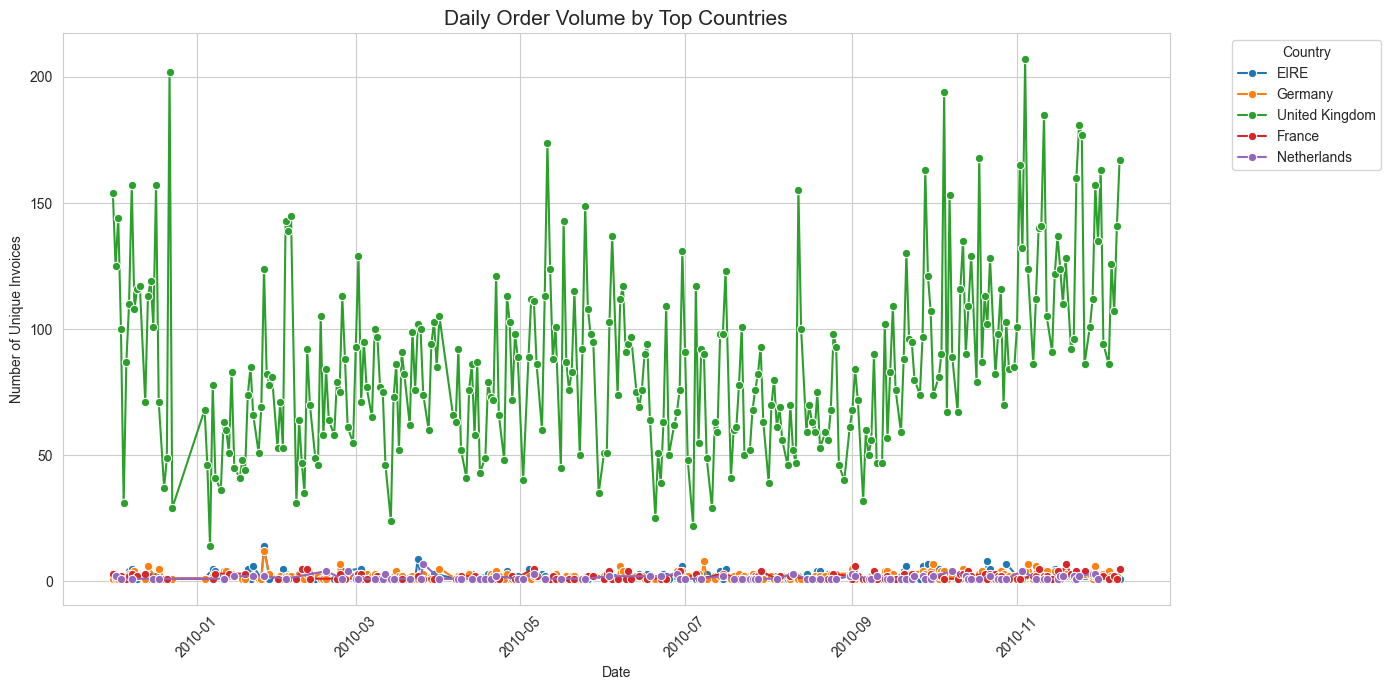

In [17]:
# Visualize the Order Volume
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create the multi-line chart
sns.lineplot(data=pd_orders, x='Date', y='OrderCount', hue='Country', marker='o')

plt.title('Daily Order Volume by Top Countries', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Number of Unique Invoices')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Robust check for "missingness"
# 1. Categorize columns by type
str_cols = [c for c, t in df.dtypes if t == 'string']
num_cols = [c for c, t in df.dtypes if t in ['double', 'float']]
other_cols = [c for c, t in df.dtypes if t not in ['string', 'double', 'float']]

# 2. Define the conditions
# More aggressive string check: Null OR Empty OR Just Spaces
str_exprs = [
    F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), c)).alias(c) 
    for c in str_cols
]

# For floats/doubles: Null OR NaN
num_exprs = [
    F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c) 
    for c in num_cols
]

# For everything else (Dates, Booleans, Integers): Just Null
other_exprs = [
    F.count(F.when(F.col(c).isNull(), c)).alias(c) 
    for c in other_cols
]

# 3. Execute the check
missing_report = df.select(str_exprs + num_exprs + other_exprs)
missing_report.show()

26/04/19 08:13:18 WARN TaskSetManager: Stage 72 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+-------+---------+-----------+-------+-----+-----------+--------+-----------+
|Invoice|StockCode|Description|Country|Price|Customer ID|Quantity|InvoiceDate|
+-------+---------+-----------+-------+-----+-----------+--------+-----------+
|      0|        0|          0|      0|    0|     107927|       0|          0|
+-------+---------+-----------+-------+-----+-----------+--------+-----------+



In [19]:
# Columns with unusual values
# Filter for zeros
zero_data_df = df.filter((F.col("Price") == 0) | (F.col("Quantity") == 0))

# Get the count
zero_count = zero_data_df.count()
print(f"Total rows with zero Price or Quantity: {zero_count}")

26/04/19 08:13:19 WARN TaskSetManager: Stage 75 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Total rows with zero Price or Quantity: 3687


In [20]:
# Zero values by column
df.select(
    F.count(F.when(F.col("Price") == 0, 1)).alias("Zero_Price"),
    F.count(F.when(F.col("Quantity") == 0, 1)).alias("Zero_Quantity")
).show()

26/04/19 08:13:19 WARN TaskSetManager: Stage 78 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+----------+-------------+
|Zero_Price|Zero_Quantity|
+----------+-------------+
|      3687|            0|
+----------+-------------+



In [21]:
# Show the first 20 rows where either is zero
zero_data_df.select("Invoice", "InvoiceDate", "Quantity", "Price", "Country").show()

+-------+-------------------+--------+-----+--------------+
|Invoice|        InvoiceDate|Quantity|Price|       Country|
+-------+-------------------+--------+-----+--------------+
| 489464|2009-12-01 10:52:00|     -96|  0.0|United Kingdom|
| 489463|2009-12-01 10:52:00|    -240|  0.0|United Kingdom|
| 489467|2009-12-01 10:53:00|    -192|  0.0|United Kingdom|
| 489521|2009-12-01 11:44:00|     -50|  0.0|United Kingdom|
| 489655|2009-12-01 17:26:00|     -44|  0.0|United Kingdom|
| 489659|2009-12-01 17:39:00|     230|  0.0|United Kingdom|
| 489660|2009-12-01 17:43:00|   -1043|  0.0|United Kingdom|
| 489663|2009-12-01 18:02:00|    -117|  0.0|United Kingdom|
| 489781|2009-12-02 11:45:00|      17|  0.0|United Kingdom|
| 489806|2009-12-02 12:42:00|    -770|  0.0|United Kingdom|
| 489820|2009-12-02 13:23:00|    -720|  0.0|United Kingdom|
| 489821|2009-12-02 13:25:00|    -240|  0.0|United Kingdom|
| 489825|2009-12-02 13:34:00|      12|  0.0|United Kingdom|
| 489861|2009-12-02 14:50:00|       1|  

26/04/19 08:13:20 WARN TaskSetManager: Stage 81 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


In [22]:
# Oh so the Quantity can be negative!
# Filter for Quantity <= 0 OR Price <= 0
invalid_values_df = df.filter((F.col("Quantity") <= 0) | (F.col("Price") <= 0))

# Get the total count
invalid_count = invalid_values_df.count()
print(f"Rows with non-positive values: {invalid_count}")

26/04/19 08:13:20 WARN TaskSetManager: Stage 82 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Rows with non-positive values: 13895


In [23]:
results = df.select(
    F.count(F.when(F.col("Quantity") == 0, 1)).alias("Qty_Zero"),
    F.count(F.when(F.col("Quantity") < 0, 1)).alias("Qty_Negative"),
    F.count(F.when(F.col("Price") == 0, 1)).alias("Price_Zero"),
    F.count(F.when(F.col("Price") < 0, 1)).alias("Price_Negative")
)

results.show()

26/04/19 08:13:21 WARN TaskSetManager: Stage 85 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


+--------+------------+----------+--------------+
|Qty_Zero|Qty_Negative|Price_Zero|Price_Negative|
+--------+------------+----------+--------------+
|       0|       12326|      3687|             3|
+--------+------------+----------+--------------+



26/04/19 08:13:22 WARN TaskSetManager: Stage 88 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


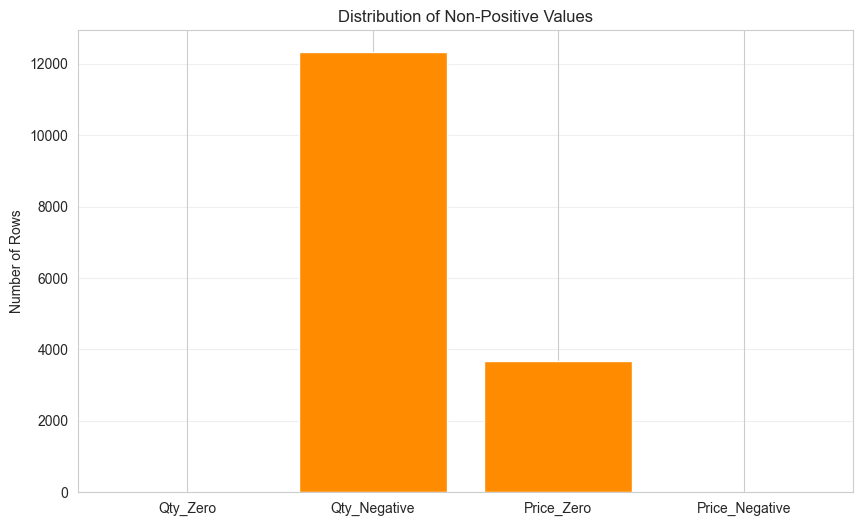

In [24]:
import matplotlib.pyplot as plt

# Convert our summary to Pandas
pd_invalid = results.toPandas().T
pd_invalid.columns = ['count']
pd_invalid.index.name = 'category'
pd_invalid.reset_index(inplace=True)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(pd_invalid['category'], pd_invalid['count'], color='darkorange')
plt.title('Distribution of Non-Positive Values')
plt.ylabel('Number of Rows')
plt.grid(axis='y', alpha=0.3)
plt.show()